In [ ]:
%cd ../..

In [2]:
import pandas as pd

df = pd.read_csv("postprocess/left_v_right/left_v_right_activation_results.csv")

In [3]:
df.head()

,left_hand_active_crop,right_hand_active_crop,left_hand_active,right_hand_active,iou,time,id,path_l,hand_in_focus
0,False,False,False,True,0.0000,0.000,C00028_RTT left side1_1,C00028/C00028_RTT left side1_1.csv,left
1,False,True,False,True,0.0000,0.533,C00028_RTT left side1_1,C00028/C00028_RTT left side1_1.csv,left
2,False,False,False,True,0.0000,1.067,C00028_RTT left side1_1,C00028/C00028_RTT left side1_1.csv,left
3,False,False,False,True,0.0025,1.600,C00028_RTT left side1_1,C00028/C00028_RTT left side1_1.csv,left
4,True,True,True,True,0.3355,2.133,C00028_RTT left side1_1,C00028/C00028_RTT left side1_1.csv,left


In [4]:
df['id'].unique()

array(['C00028_RTT left side1_1', 'C00028_RTT right side1_1',
       'C00028_RTT right side1_2', 'C00028_RTT left side1_2',
       'C00023_RTT right side1_2', 'C00023_RTT right side1_1',
       'C00023_RTT left side1_1', 'C00023_RTT left side1_2',
       'C00029_RTT left side1_1', 'C00029_RTT right side1_1',
       'C00029_RTT left side1_2', 'C00029_RTT right side1_2',
       'C00024_RTT left side1_1', 'C00024_RTT right side1_1',
       'C00024_RTT right side1_2', 'C00024_RTT left side1_2',
       'C00022_RTT left side1_1', 'C00022_RTT right side1_1',
       'C00022_RTT right side1_2', 'C00022_RTT left side1_2'],
      dtype=object)

In [5]:
import numpy as np
import pandas as pd


def add_gt(adf: pd.DataFrame, gt_prims: list[str], gt_times: list[float]) -> pd.DataFrame:
    """
    Add a 'gt_active' column to `adf` based on gt_prims and gt_times.
    
    Each row in `adf` represents a time segment centered or starting at `time`.
    For each segment (time_i -> time_{i+1}), we assign:
      - 'ACTIVE' if all overlapping ground-truth primitives are active (reach, reposition, transport, stabilize)
      - 'IDLE' if all are idle
      - 'BOTH' if mixed

    Parameters
    ----------
    adf : pd.DataFrame
        Must contain a 'time' column (in seconds, increasing).
    gt_prims : list[str]
        Ground truth primitive labels (e.g., ['idle', 'reach', ...]).
    gt_times : list[float]
        Start times for each primitive; same length as gt_prims.

    Returns
    -------
    pd.DataFrame
        The same `adf` with an added 'gt_active' column.
    """
    # Define active primitives
    active_prims = {"reach", "reposition", "transport"}

    # Build primitive intervals [(t_start, t_end, label)]
    gt_intervals = []
    for i in range(len(gt_prims)):
        t0 = gt_times[i]
        t1 = gt_times[i + 1] if i + 1 < len(gt_times) else np.inf
        gt_intervals.append((t0, t1, gt_prims[i]))

    # Compute segment intervals from adf
    seg_starts = adf["time"].values
    seg_ends = np.concatenate([seg_starts[1:], [seg_starts[-1] + (seg_starts[-1] - seg_starts[-2])]])

    gt_labels = []
    for t0, t1 in zip(seg_starts, seg_ends):
        # find gt primitives overlapping this interval
        overlapping = [label for g0, g1, label in gt_intervals if not (g1 <= t0 or g0 >= t1)]

        if not overlapping:
            gt_labels.append("IDLE/STABILIZE")
        elif all(l in active_prims for l in overlapping):
            gt_labels.append("ACTIVE")
        elif all(l == "idle" for l in overlapping):
            gt_labels.append("IDLE/STABILIZE")
        else:
            gt_labels.append("EITHER")

    adf["gt_active"] = gt_labels


def get_activation_results(adf: pd.DataFrame, handedness: str) -> dict:
    """
    Compute activation results for the given handedness.

    Parameters
    ----------
    adf : pd.DataFrame
        DataFrame containing model answers and ground truth labels.
    handedness : str
        'left' or 'right' indicating the active hand.
    """

    # Active hand is "active", other hand is "idle"
    active_filter = adf["gt_active"] == "ACTIVE"

    hand = handedness.lower()
    other = "right" if hand == "left" else "left"
    # Column names
    same_hand_col = f"{hand}_hand_active"
    same_hand_crop_col = f"{hand}_hand_active_crop"
    cross_hand_col = f"{other}_hand_active"
    cross_hand_crop_col = f"{other}_hand_active_crop"

    # Filter to active-hand segments
    adf_active = adf[active_filter].copy()

    # Get Same/Cross hand activations
    adf_active["Active Hand [Pred w/o Cropping]"] = adf_active[same_hand_col]
    adf_active["Inactive Hand [Pred w/o Cropping]"] = adf_active[cross_hand_col]
    adf_active["Active Hand [Pred w/ Cropping]"] = adf_active[same_hand_crop_col]
    adf_active["Inactive Hand [Pred w/ Cropping]"] = adf_active[cross_hand_crop_col]

    def get_iou_regime(x):
        if pd.isna(x):
            return "Failed to Crop"
        elif x >= 0.1:
            return "Hands Overlap"
        else:
            return "Hands Separate"

    adf_active["IoU Regime"] = adf_active["iou"].apply(get_iou_regime)

    cols_to_keep = [
        "Active Hand [Pred w/o Cropping]",
        "Inactive Hand [Pred w/o Cropping]",
        "Active Hand [Pred w/ Cropping]",
        "Inactive Hand [Pred w/ Cropping]",
        "IoU Regime",
    ]

    return adf_active[cols_to_keep].copy()


In [6]:
from data.utils_strokerehab import PrimitiveLabelUtils, DataPaths
import os

In [7]:
unique_path_ls = df['path_l'].unique()

results = []
for path_l in unique_path_ls:
    df_for_video = df[df['path_l'] == path_l].copy()
    path_l = os.path.join(DataPaths.RAW_LABEL_DIR, path_l)
    gt_prims, gt_times = PrimitiveLabelUtils.convert_labels_to_prims_times(path_l)
    add_gt(df_for_video, gt_prims, gt_times)
    video_results = get_activation_results(df_for_video, df_for_video.iloc[0]['hand_in_focus'])
    results.append(video_results)
results = pd.concat(results)


In [8]:
N = len(results)
agg_results = results.groupby("IoU Regime").sum() / N
gt_same_hand_activation = results['IoU Regime'].value_counts() / N
gt_cross_hand_activation = gt_same_hand_activation.copy()
gt_cross_hand_activation.values[:] = 0.0

agg_results['Active Hand [Ground Truth]'] = gt_same_hand_activation
agg_results['Inactive Hand [Ground Truth]'] = gt_cross_hand_activation

In [9]:
agg_results

,Active Hand [Pred w/o Cropping],Inactive Hand [Pred w/o Cropping],Active Hand [Pred w/ Cropping],Inactive Hand [Pred w/ Cropping],Active Hand [Ground Truth],Inactive Hand [Ground Truth]
IoU Regime,,,,,,
Failed to Crop,0.240690,0.258856,0.252498,0.259764,0.270663,0.0
Hands Overlap,0.216167,0.193460,0.228883,0.153497,0.234332,0.0
Hands Separate,0.439600,0.201635,0.418710,0.019982,0.495005,0.0


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from typing import Sequence, Tuple, Dict

def _wilson_interval(p: float, n: int, z: float = 1.96) -> Tuple[float, float]:
    if n <= 0:
        return (0.0, 0.0)
    p = float(np.clip(p, 0.0, 1.0))
    z2 = z * z
    denom = 1.0 + z2 / n
    center = (p + z2 / (2 * n)) / denom
    half = (z / denom) * np.sqrt((p * (1.0 - p) / n) + (z2 / (4.0 * n * n)))
    lo, hi = center - half, center + half
    return (max(0.0, lo), min(1.0, hi))

def plot_stacked_bars(df: pd.DataFrame, N: int) -> None:
    """
    Groups (left->right): GT, Pred, Crop
    Within each group: Same Hand, Cross Hand
    Within each bar (bottom->top): Failed to Crop, Hands Separate, Hands Overlap
    """
    required_rows = ['Failed to Crop', "Hands Separate", "Hands Overlap"]
    required_cols_by_group: Dict[str, Tuple[str, str]] = {
        "Ground Truth":   ("Active Hand [Ground Truth]",   "Inactive Hand [Ground Truth]"),
        "Pred w/o Cropping": ("Active Hand [Pred w/o Cropping]", "Inactive Hand [Pred w/o Cropping]"),
        "Pred w/ Cropping": ("Active Hand [Pred w/ Cropping]", "Inactive Hand [Pred w/ Cropping]"),
    }
    missing = [c for cols in required_cols_by_group.values() for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in df: {missing}")

    df2 = df.copy()
    try:
        df2 = df2.reindex(required_rows)
    except Exception:
        existing = [r for r in required_rows if r in df2.index]
        df2 = df2.loc[existing]

    stack_order = required_rows
    groups = ["Ground Truth", "Pred w/o Cropping", "Pred w/ Cropping"]

    width = 0.34
    x_groups = np.arange(len(groups))
    x_same = x_groups - width/2
    x_cross = x_groups + width/2

    fig, ax = plt.subplots(figsize=(12, 7))

    # colors (bottom->top)
    stack_colors = {
        "Failed to Crop": "#92928f",
        "Hands Separate": "#56b4e8",
        "Hands Overlap": "#e49f22",
    }

    same_cols = {g: required_cols_by_group[g][0] for g in groups}
    cross_cols = {g: required_cols_by_group[g][1] for g in groups}

    def draw_series(xpos: np.ndarray, col_selector: Dict[str, str], hatch: str = ""):
        bottoms = np.zeros_like(xpos, dtype=float)
        for regime in stack_order:
            vals = np.array([
                df2.loc[regime, col_selector[g]] if (regime in df2.index) else 0.0
                for g in groups
            ], dtype=float)
            ax.bar(
                xpos, vals, bottom=bottoms, width=width,
                color=stack_colors[regime], edgecolor="black", linewidth=1.0, hatch=hatch,
                label=regime  # we'll dedupe legend later
            )
            bottoms += vals
        return xpos.copy(), bottoms.copy()

    centers_same, tops_same = draw_series(x_same, same_cols, hatch="")
    centers_cross, tops_cross = draw_series(x_cross, cross_cols, hatch="///")

    # 95% CI (no dot markers)
    def add_ci(centers: Sequence[float], totals: Sequence[float]):
        lowers, uppers = [], []
        for p in totals:
            lo, hi = _wilson_interval(float(p), int(N), z=1.96)
            lowers.append(max(0.0, float(p) - lo))
            uppers.append(max(0.0, hi - float(p)))
        yerr = np.vstack([lowers, uppers])
        ax.errorbar(
            centers, totals, yerr=yerr, fmt='none',
            capsize=6, elinewidth=2.2, ecolor="black"
        )

    add_ci(centers_same, tops_same)
    add_ci(centers_cross, tops_cross)

    # Labels / ticks (big fonts)
    ax.set_ylabel("Motion Detection Rate", fontsize=32)
    ax.set_ylim(0.0, max(1.0, 1.05 * max(tops_same.max(), tops_cross.max())))
    ax.set_xticks(x_groups, labels=groups, fontsize=24, rotation=15)
    ax.tick_params(axis='y', labelsize=24, width=2, length=8)
    ax.tick_params(axis='x', width=2, length=8)

    # --- Single-column legend on the right ---
    stack_handles = [Patch(facecolor=stack_colors[s], edgecolor="black", label=s) for s in stack_order]
    same_proxy  = Patch(facecolor="white", edgecolor="black", hatch="", label="Same Hand")
    cross_proxy = Patch(facecolor="white", edgecolor="black", hatch="///", label="Cross Hand")

    handles = stack_handles + [same_proxy, cross_proxy]

    ax.legend(
        handles=handles,
        fontsize=24,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),  # to the right of the plot
        borderaxespad=0.0,
        ncol=1
    )

    ax.grid(axis="y", linestyle="--", linewidth=1.2, alpha=0.5)
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    fig.tight_layout()
    plt.savefig("left_v_right_activation_results.pdf", bbox_inches='tight')
    plt.show()


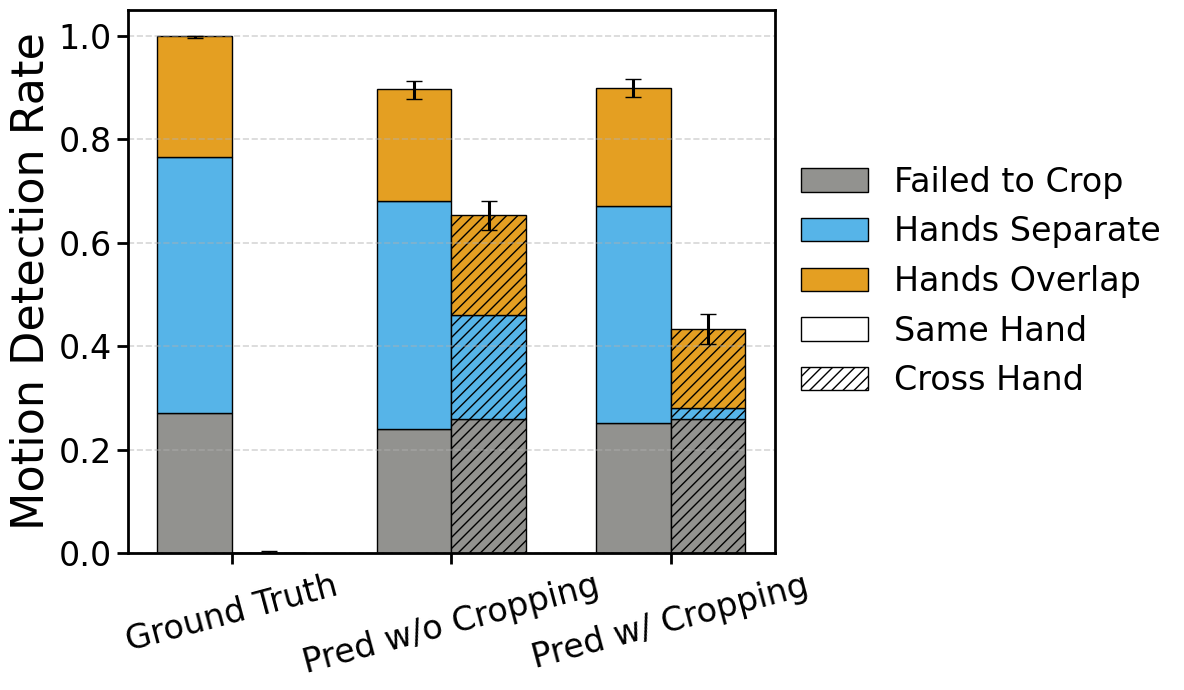

In [11]:
plot_stacked_bars(agg_results, N)

In [115]:

from lmms_eval.tasks.strokerehab.utils_primitives import load_strokerehab_primitives_dataset
ds = load_strokerehab_primitives_dataset(activity='RTT left side,RTT right side')
df = ds['test'].to_pandas()
control_mask = ~df['stroke']
first_rep_mask = df['path_v'].str.contains('RTT right side1') | df['path_v'].str.contains('RTT left side1')
df = df[control_mask & first_rep_mask]
patient_has_all_four = (df.groupby('patient')['id'].count() == 4)
df = df[df['patient'].isin(patient_has_all_four[patient_has_all_four].index.tolist())]
control_patient_list = "C00022,C00023,C00024,C00028,C00029".split(',')
df = df[df['patient'].isin(control_patient_list)].copy()

In [116]:
len(df)

20

In [117]:
print(N)

1101
